In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", *args, "-q"])

# Upgrade to versions required by jina-embeddings-v5-text-nano
pip("install", "--upgrade", "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cu121")
pip("install", "--upgrade", "transformers>=4.57.0", "peft>=0.15.2", "accelerate")
pip("install", "torch_geometric")
pip("install", "python-dotenv", "sentencepiece")

print("✅ Installs done — RESTART RUNTIME NOW, then run from Cell 2 onwards")

✅ Installs done — RESTART RUNTIME NOW, then run from Cell 2 onwards


In [ ]:

import os, gc, warnings, textwrap
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv
from google.colab import drive

warnings.filterwarnings("ignore")
drive.mount("/content/drive")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Torch  : {torch.__version__}")

# ── Experiment toggle ────────────────────────────────────────
# Set SUBSET_MODE=False and re-run identically for full dataset.
SUBSET_MODE = False
SUBSET_N    = 1000

# ── Embedding dims ───────────────────────────────────────────
# Jina Matryoshka supports: 32 / 64 / 128 / 256 / 512 / 768
# 256 balances quality vs GPU RAM. GAT output matches this so
# semantic & graph embeddings are directly comparable.
JINA_TRUNCATE_DIM = 256
GAT_EMB_DIM       = 256

# ── Graph construction knobs ─────────────────────────────────
TOP_N_ACTORS     = 8    # was 5 — more cast gives richer graph
TOP_N_KEYWORDS   = 12   # per movie (in text + graph)
MIN_KW_FREQ      = 5    # only keywords appearing in ≥ N movies
DECADE_STEP      = 10   # group years into N-year buckets

# ── Paths ────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/moviematcher"
CACHE_DIR = "/content/cache"
Path(CACHE_DIR).mkdir(exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
Torch  : 2.10.0+cu128


In [ ]:

print("Loading CSVs…")
movies          = pd.read_csv(f"{DATA_DIR}/graph_movies.csv")
movie_genres    = pd.read_csv(f"{DATA_DIR}/graph_movie_genre.csv")
movie_keywords  = pd.read_csv(f"{DATA_DIR}/graph_movie_keyword.csv")
movie_directors = pd.read_csv(f"{DATA_DIR}/graph_movie_director.csv")
movie_actors    = pd.read_csv(f"{DATA_DIR}/graph_movie_actor.csv")
movie_language  = pd.read_csv(f"{DATA_DIR}/graph_movie_language.csv")
movie_country   = pd.read_csv(f"{DATA_DIR}/graph_movie_country.csv")

for name, df in [("movies", movies), ("genres", movie_genres),
                  ("keywords", movie_keywords), ("directors", movie_directors),
                  ("actors", movie_actors), ("languages", movie_language),
                  ("countries", movie_country)]:
    print(f"  {name:<12}: {len(df):,} rows")



Loading CSVs…
  movies      : 59,328 rows
  genres      : 145,779 rows
  keywords    : 337,990 rows
  directors   : 65,589 rows
  actors      : 411,757 rows
  languages   : 77,233 rows
  countries   : 68,765 rows


In [ ]:

def select_subset(df, n, mode=True):
    if not mode:
        return df.copy()
    d = df.copy()
    sort_cols = [c for c in ["data_completeness_score", "rating_count"] if c in d.columns]
    if sort_cols:
        d = d.sort_values(sort_cols, ascending=False)
    return d.head(n).reset_index(drop=True)

movies_subset = select_subset(movies, SUBSET_N, SUBSET_MODE)
subset_ids    = set(movies_subset["movieId"])
print(f"Subset: {len(movies_subset):,} movies  ({'SUBSET' if SUBSET_MODE else 'FULL'})")

# Filter all entity tables
genres_sub    = movie_genres[movie_genres["movieId"].isin(subset_ids)].copy()
directors_sub = movie_directors[movie_directors["movieId"].isin(subset_ids)].copy()
actors_sub    = movie_actors[
    movie_actors["movieId"].isin(subset_ids) &
    (movie_actors["cast_order"] < TOP_N_ACTORS)
].copy()
languages_sub = movie_language[movie_language["movieId"].isin(subset_ids)].copy()
countries_sub = movie_country[movie_country["movieId"].isin(subset_ids)].copy()

# Keywords: filter to those appearing in ≥ MIN_KW_FREQ movies in the subset
kw_all        = movie_keywords[movie_keywords["movieId"].isin(subset_ids)].copy()
kw_freq       = kw_all.groupby("keyword_name")["movieId"].nunique()
valid_kws     = set(kw_freq[kw_freq >= MIN_KW_FREQ].index)
keywords_sub  = kw_all[kw_all["keyword_name"].isin(valid_kws)].copy()

print(f"  genres:    {len(genres_sub):,}")
print(f"  directors: {len(directors_sub):,}")
print(f"  actors:    {len(actors_sub):,}  (top {TOP_N_ACTORS} cast)")
print(f"  keywords:  {len(keywords_sub):,}  ({len(valid_kws)} unique, freq≥{MIN_KW_FREQ})")
print(f"  languages: {len(languages_sub):,}")
print(f"  countries: {len(countries_sub):,}")


Subset: 59,328 movies  (FULL)
  genres:    145,779
  directors: 65,589
  actors:    347,455  (top 8 cast)
  keywords:  302,489  (10068 unique, freq≥5)
  languages: 77,233
  countries: 68,765


In [ ]:
# Each movie connects to its decade node (1970s, 1980s, …).
# Two movies from the same decade share this neighbor → their
# graph embeddings get softly pulled together through GAT message
# passing. This encodes era/zeitgeist without any explicit label.

def year_to_decade_label(year):
    """E.g. 1975 → '1970s', 2003 → '2000s'"""
    if pd.isna(year):
        return None
    decade = (int(year) // DECADE_STEP) * DECADE_STEP
    return f"{decade}s"

movies_subset["decade"] = movies_subset["year_final"].apply(year_to_decade_label)

# Build movie→decade edge table
decade_rows = movies_subset[["movieId", "decade"]].dropna(subset=["decade"])


print(f"Decade coverage: {len(decade_rows):,} movies across "
      f"{decade_rows['decade'].nunique()} decades: "
      f"{sorted(decade_rows['decade'].unique())}")

# i want to print # of movies in each decade.
print(decade_rows.groupby('decade').count())


Decade coverage: 59,326 movies across 15 decades: ['1880s', '1890s', '1900s', '1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
        movieId
decade         
1880s         2
1890s        51
1900s        93
1910s       226
1920s       524
1930s      2078
1940s      2344
1950s      2999
1960s      3377
1970s      4558
1980s      4656
1990s      6119
2000s     10589
2010s     18593
2020s      3117


In [ ]:
# All available structured fields go into one rich string.
# Jina encodes this to produce embedding_semantic.
# Language + country are now included (they carry cultural signal
# that overview alone might miss — "a Japanese horror film" is
# meaningfully different from "a horror film").

def build_rich_text(row, genres_map, directors_map, actors_map,
                    keywords_map, lang_map, country_map):
    parts = []

    title = str(row.get("title_clean", "") or "").strip()
    year  = str(int(row["year_final"])) if pd.notna(row.get("year_final")) else ""
    decade = str(row.get("decade", "") or "")
    if title:
        suffix = f"({year}, {decade})" if year and decade else f"({year})" if year else ""
        parts.append(f"{title} {suffix}".strip())

    overview = str(row.get("overview_tmdb", "") or "").strip()
    if overview:
        parts.append(overview)

    mid = row["movieId"]

    genres = genres_map.get(mid, [])
    if genres:
        parts.append("Genres: " + ", ".join(genres))

    directors = directors_map.get(mid, [])
    if directors:
        parts.append("Director: " + ", ".join(directors))

    actors = actors_map.get(mid, [])
    if actors:
        parts.append("Cast: " + ", ".join(actors))

    kws = keywords_map.get(mid, [])[:TOP_N_KEYWORDS]
    if kws:
        parts.append("Keywords: " + ", ".join(kws))

    langs = lang_map.get(mid, [])
    if langs:
        parts.append("Language: " + ", ".join(langs))

    countries = country_map.get(mid, [])
    if countries:
        parts.append("Country: " + ", ".join(countries))

    return " | ".join(parts)


# Lookup maps
genres_map    = genres_sub.groupby("movieId")["genre_name"].apply(list).to_dict()
directors_map = directors_sub.groupby("movieId")["director_name"].apply(list).to_dict()
actors_map    = actors_sub.groupby("movieId")["actor_name"].apply(list).to_dict()
keywords_map  = keywords_sub.groupby("movieId")["keyword_name"].apply(list).to_dict()
lang_map      = languages_sub.groupby("movieId")["language_name"].apply(list).to_dict()
country_map   = countries_sub.groupby("movieId")["country_code"].apply(list).to_dict()

movies_subset["rich_text"] = movies_subset.apply(
    build_rich_text, axis=1,
    args=(genres_map, directors_map, actors_map, keywords_map, lang_map, country_map)
)

print("Sample:")
print(movies_subset["rich_text"].iloc[0][:300])



Sample:
Toy Story (1995, 1990s) | Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to


In [ ]:

# At query time (Cell E), we use task="retrieval" with prompt_name="query"
# which is asymmetric — Jina applies a different prompt prefix to the
# query vs documents, improving retrieval quality.
#
# truncate_dim=256 uses Matryoshka: the model was trained so that
# the first 256 dimensions alone form a well-structured space.

from transformers import AutoModel

print("Loading jina-embeddings-v5-text-nano ...")
jina_model = AutoModel.from_pretrained(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
jina_model = jina_model.to(DEVICE)
jina_model.eval()
print("✅ Jina v5 nano loaded")



BATCH_SIZE = 128  # adjust if OOM

texts     = movies_subset["rich_text"].tolist()
movie_ids = movies_subset["movieId"].tolist()

all_embs = []
with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Encoding"):
        batch = texts[i : i + BATCH_SIZE]
        embs  = jina_model.encode(
            texts=batch,
            task="text-matching",
            truncate_dim=JINA_TRUNCATE_DIM,
        )
        # encode() may return numpy or tensor
        if isinstance(embs, torch.Tensor):
            embs = embs.cpu().float().numpy()
        all_embs.append(embs)




semantic_embeddings = np.vstack(all_embs).astype(np.float32)
# L2-normalize so cosine sim == dot product
norms = np.linalg.norm(semantic_embeddings, axis=1, keepdims=True)
semantic_embeddings = semantic_embeddings / np.maximum(norms, 1e-8)

print(f" Semantic embeddings: {semantic_embeddings.shape}")  # (N, 256)


# Save to disk — avoids re-encoding if Colab disconnects
np.save(f"{CACHE_DIR}/semantic_embeddings.npy", semantic_embeddings)
pd.Series(movie_ids).to_csv(f"{CACHE_DIR}/movie_ids.csv", index=False)
print(f" Saved to {CACHE_DIR}/")

# we free Jina model from GPU RAM before GAT training
del jina_model
gc.collect()
torch.cuda.empty_cache()

# These become:
#   1. embedding_semantic stored on Movie nodes
#   2. initial node features fed into the GAT


Loading jina-embeddings-v5-text-nano ...


config.json: 0.00B [00:00, ?B/s]

configuration_jina_embeddings_v5.py:   0%|          | 0.00/137 [00:00<?, ?B/s]

configuration_eurobert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- configuration_eurobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- configuration_jina_embeddings_v5.py
- configuration_eurobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/582 [00:00<?, ?B/s]

✅ Jina v5 nano loaded



Encoding: 100%|██████████| 464/464 [40:07<00:00,  5.19s/it]


 Semantic embeddings: (59328, 256)
 Saved to /content/cache/


In [ ]:

# Threshold guidance for a subset of ~1000-1500 movies with Jina:
#   0.55 → gets everything (all top-10 per movie), useless
#   0.80 → ~4900 pairs (good, ~4-5 per movie on average)
#   0.85 → ~1000-2000 pairs (stricter, only truly similar movies)
#
# Rule of thumb: aim for 3-6 positive pairs per movie on average.
# At subset size 1000: target ~3000-6000 total pairs.
# For 1500 movies, 0.82 is a good starting point.
#
# TOP_K_SEM caps the max neighbors per movie so one very-connected
# movie doesn't dominate the training signal. 5 is cleaner than 10
# for a small subset because it forces only the closest matches.

TOP_K_SEM  = 5
SIM_THRESH = 0.7  # raise from 0.55; tune until you get ~3-6 avg pairs/movie

print("Mining semantic positive pairs...")
emb_t = torch.tensor(semantic_embeddings, device=DEVICE)

positive_pairs = []
CHUNK = 256

for start in tqdm(range(0, len(emb_t), CHUNK)):
    end   = min(start + CHUNK, len(emb_t))
    block = emb_t[start:end] @ emb_t.T         # (chunk, N)

    # Mask self-similarity
    for local_i in range(end - start):
        block[local_i, start + local_i] = -1.0

    topk_vals, topk_idx = torch.topk(block, k=TOP_K_SEM, dim=1)

    for li, gi in enumerate(range(start, end)):
        for j, s in zip(topk_idx[li].tolist(), topk_vals[li].tolist()):
            if s >= SIM_THRESH:
                positive_pairs.append((gi, j, float(s)))

sem_pairs_df = pd.DataFrame(positive_pairs, columns=["i", "j", "sim"])
sem_pairs_df.to_parquet(f"{CACHE_DIR}/sem_pairs.parquet", index=False)

n_movies = len(movie_ids)
avg_pairs = len(sem_pairs_df) / n_movies if n_movies > 0 else 0
print(f"✅ {len(sem_pairs_df):,} semantic positive pairs")
print(f"   avg per movie: {avg_pairs:.1f}  (target: 3-6)")
print(f"   coverage: {sem_pairs_df['i'].nunique()}/{n_movies} movies have at least one positive")

if avg_pairs > 8:
    print("⚠️  avg > 8: consider raising SIM_THRESH to 0.84-0.86")
elif avg_pairs < 2:
    print("⚠️  avg < 2: consider lowering SIM_THRESH to 0.78-0.80")
else:
    print("✅ pair count looks healthy")

del emb_t
gc.collect()
torch.cuda.empty_cache()

Mining semantic positive pairs...


100%|██████████| 232/232 [00:04<00:00, 46.99it/s]


✅ 296,640 semantic positive pairs
   avg per movie: 5.0  (target: 3-6)
   coverage: 59328/59328 movies have at least one positive
✅ pair count looks healthy


In [ ]:
# Node types:
#   Movie, Genre, Director, Actor, Keyword, Language, Country, Decade
#
# Why each matters in the graph (not just in text):
#   Genre    → defines movie clusters; used for sliders
#   Director → style fingerprint; useful for "more like Kubrick"
#   Actor    → career/casting signal; used in agent-persona reasoning
#   Keyword  → thematic signal; used for "same themes" search
#   Language → cultural cluster; "Japanese cinema" finds a cluster
#   Country  → production culture signal
#   Decade   → temporal cluster; "1990s feel" query becomes possible

def build_heterodata(movies_sub, genres_s, directors_s, actors_s,
                     keywords_s, languages_s, countries_s, decade_rows,
                     semantic_embs, movie_id_list, emb_dim=256):

    mid2idx = {mid: i for i, mid in enumerate(movie_id_list)}
    D = emb_dim
    torch.manual_seed(42)

    def make_vocab_and_idx(series):
        vocab = sorted(series.dropna().unique())
        return vocab, {v: i for i, v in enumerate(vocab)}

    genre_vocab,    g2idx  = make_vocab_and_idx(genres_s["genre_name"])
    dir_vocab,      d2idx  = make_vocab_and_idx(directors_s["director_id"])
    act_vocab,      a2idx  = make_vocab_and_idx(actors_s["actor_id"])
    kw_vocab,       kw2idx = make_vocab_and_idx(keywords_s["keyword_name"])
    lang_vocab,     l2idx  = make_vocab_and_idx(languages_s["language_name"])
    country_vocab,  c2idx  = make_vocab_and_idx(countries_s["country_code"])
    decade_vocab,   dc2idx = make_vocab_and_idx(decade_rows["decade"])

    data = HeteroData()
    data["movie"].x    = torch.tensor(semantic_embs, dtype=torch.float32)
    # All entity nodes: small random init (learned during training)
    for nt, n in [("genre", len(genre_vocab)), ("director", len(dir_vocab)),
                  ("actor", len(act_vocab)),   ("keyword",  len(kw_vocab)),
                  ("language", len(lang_vocab)), ("country", len(country_vocab)),
                  ("decade", len(decade_vocab))]:
        data[nt].x = torch.randn(n, D) * 0.02

    def edges(df, src_col, dst_col, src_map, dst_map):
        df = df.dropna(subset=[src_col, dst_col])
        srcs, dsts = [], []
        for r in df.itertuples(index=False):
            s = src_map.get(getattr(r, src_col))
            d = dst_map.get(getattr(r, dst_col))
            if s is not None and d is not None:
                srcs.append(s); dsts.append(d)
        if not srcs:
            return torch.zeros((2, 0), dtype=torch.long)
        return torch.tensor([srcs, dsts], dtype=torch.long)

    mg  = edges(genres_s,    "movieId", "genre_name",   mid2idx, g2idx)
    md  = edges(directors_s, "movieId", "director_id",  mid2idx, d2idx)
    ma  = edges(actors_s,    "movieId", "actor_id",     mid2idx, a2idx)
    mkw = edges(keywords_s,  "movieId", "keyword_name", mid2idx, kw2idx)
    ml  = edges(languages_s, "movieId", "language_name",mid2idx, l2idx)
    mc  = edges(countries_s, "movieId", "country_code", mid2idx, c2idx)
    mdc = edges(decade_rows, "movieId", "decade",       mid2idx, dc2idx)

    edge_defs = [
        (mg,  "movie","has_genre",    "genre"),
        (md,  "movie","directed_by",  "director"),
        (ma,  "movie","acted_in",     "actor"),
        (mkw, "movie","has_keyword",  "keyword"),
        (ml,  "movie","in_language",  "language"),
        (mc,  "movie","from_country", "country"),
        (mdc, "movie","in_decade",    "decade"),
    ]
    for eidx, src, rel, dst in edge_defs:
        data[src, rel, dst].edge_index         = eidx
        rev_rel = f"rev_{rel}"
        data[dst, rev_rel, src].edge_index     = eidx.flip(0)

    meta = dict(
        mid2idx=mid2idx, g2idx=g2idx, d2idx=d2idx, a2idx=a2idx,
        kw2idx=kw2idx, l2idx=l2idx, c2idx=c2idx, dc2idx=dc2idx,
        genre_vocab=genre_vocab, dir_vocab=dir_vocab, act_vocab=act_vocab,
        kw_vocab=kw_vocab, lang_vocab=lang_vocab, country_vocab=country_vocab,
        decade_vocab=decade_vocab,
    )
    return data, meta


pyg_data, graph_meta = build_heterodata(
    movies_subset, genres_sub, directors_sub, actors_sub,
    keywords_sub, languages_sub, countries_sub, decade_rows,
    semantic_embeddings, movie_ids, emb_dim=JINA_TRUNCATE_DIM
)
pyg_data = pyg_data.to(DEVICE)

print("✅ HeteroData built:")
for nt in pyg_data.node_types:
    print(f"   {nt:<12} nodes: {pyg_data[nt].x.shape[0]:>5}")
print()
for et in pyg_data.edge_types:
    n = pyg_data[et].edge_index.shape[1]
    if n > 0:
        print(f"   {str(et):<50} edges: {n:>6,}")


✅ HeteroData built:
   movie        nodes: 59328
   genre        nodes:    23
   director     nodes: 25966
   actor        nodes: 65477
   keyword      nodes: 10068
   language     nodes:   160
   country      nodes:   173
   decade       nodes:    15

   ('movie', 'has_genre', 'genre')                    edges: 145,779
   ('genre', 'rev_has_genre', 'movie')                edges: 145,779
   ('movie', 'directed_by', 'director')               edges: 65,589
   ('director', 'rev_directed_by', 'movie')           edges: 65,589
   ('movie', 'acted_in', 'actor')                     edges: 347,455
   ('actor', 'rev_acted_in', 'movie')                 edges: 347,455
   ('movie', 'has_keyword', 'keyword')                edges: 302,489
   ('keyword', 'rev_has_keyword', 'movie')            edges: 302,489
   ('movie', 'in_language', 'language')               edges: 77,233
   ('language', 'rev_in_language', 'movie')           edges: 77,233
   ('movie', 'from_country', 'country')               edges: 

In [ ]:
# Design inspired by KERAG_R and Enhanced Recommendation paper:
#
#  - KERAG_R: uses GAT attention to score (movie, entity) triples.
#    Attention weight × (h_movie · h_entity) = triple relevance.
#    We replicate this with our KG loss.
#
#  - Enhanced Rec: initial node features come from a text encoder
#    (here: Jina), then GNN propagates and mixes them.
#    "The key design: using LLM to create better initial node
#    embeddings before graph propagation."
#
#  - Genre paper: genre-centroid pull in loss.
#
# Architecture:
#   1. Project all node types to shared GAT_EMB_DIM
#   2. Layer 1 GAT: movie ← entities (reverse edges)
#   3. Layer 2 GAT: entities ← movie (forward edges)
#   4. Residual + LayerNorm after each layer
#   5. L2-normalize outputs


# ── WHAT IS THE ATTENTION? ────────────────────────────────────
# In a plain GNN, every neighbor j of node i
# contributes equally to the aggregated message:
#   h_i_new = mean({ h_j : j ∈ N(i) })
#
# In a GAT (Graph Attention Network), each neighbor j gets a
# learned attention weight α_ij before aggregation:
#   h_i_new = Σ_j  α_ij · W · h_j
#
# α_ij is computed as:
#   e_ij  = LeakyReLU( a^T · [W·h_i || W·h_j] )   (raw score)
#   α_ij  = softmax over j in N(i) of e_ij
#
# So: for movie "Alien", its genre neighbors (Sci-Fi, Horror) each
# get a different α. If Alien's semantic embedding is closer to
# Horror than Sci-Fi (based on its overview), Horror gets higher α
# and contributes more to the aggregated movie embedding.
# This is KERAG_R's "attention weight × (h_movie · h_entity)"
# triple scoring, implemented end-to-end.
#
# Multi-head: we use 4 attention heads. Each head learns a
# different attention pattern, and the outputs are concatenated
# then projected back to out_dim. This lets the model attend to
# different aspects simultaneously.
#
# ── WHAT ARE THE OUTPUT EMBEDDINGS? ──────────────────────────
# After training, we call model(pyg_data) one final time and take
# final_h["movie"]. These are the post-aggregation embeddings:
# each movie's vector has absorbed a weighted summary of its
# structural neighborhood (genres, directors, actors, keywords,
# language, country, decade). They are NOT the input semantic
# embeddings — they are transformed by the learned W and a weights.
#
# We keep BOTH:
#   embedding_semantic (256d) — for vibe/text query search
#   embedding_graph    (256d) — for structural similarity + sliders
#
# ── ARCHITECTURE ─────────────────────────────────────────────
# Layer 1: ALL entity types → Movie  (movie aggregates from neighbors)
# Layer 2: Movie → ALL entity types  (entities update from movies)
# Both layers use GATConv with residual + LayerNorm.
# Output: L2-normalized embeddings for all node types.

ENTITY_TYPES = ["genre", "director", "actor", "keyword", "language", "country", "decade"]

class MovieGAT(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, heads: int = 4, dropout: float = 0.2):
        super().__init__()
        assert out_dim % heads == 0
        head_dim = out_dim // heads

        # Linear projection for every node type into shared space
        all_types = ["movie"] + ENTITY_TYPES
        self.proj = nn.ModuleDict({
            nt: nn.Linear(in_dim, out_dim, bias=False) for nt in all_types
        })

        # Layer 1: entity → movie (one GATConv per entity type)
        self.gat1 = nn.ModuleDict({
            nt: GATConv((out_dim, out_dim), head_dim, heads=heads,
                        add_self_loops=False, dropout=dropout)
            for nt in ENTITY_TYPES
        })

        # Layer 2: movie → entity (one GATConv per entity type)
        self.gat2 = nn.ModuleDict({
            nt: GATConv((out_dim, out_dim), head_dim, heads=heads,
                        add_self_loops=False, dropout=dropout)
            for nt in ENTITY_TYPES
        })

        self.ln_movie = nn.LayerNorm(out_dim)
        self.ln_ent   = nn.LayerNorm(out_dim)
        self.drop     = nn.Dropout(dropout)

        # Relation name mapping: entity type → forward/reverse relation names
        self._rel_fwd = {
            "genre":    "has_genre",
            "director": "directed_by",
            "actor":    "acted_in",
            "keyword":  "has_keyword",
            "language": "in_language",
            "country":  "from_country",
            "decade":   "in_decade",
        }

    def forward(self, data):
        h = {nt: F.relu(self.proj[nt](data[nt].x))
             for nt in ["movie"] + ENTITY_TYPES}

        # ── Layer 1: entities → movie ─────────────────────────
        msgs = []
        for nt in ENTITY_TYPES:
            rev_rel = f"rev_{self._rel_fwd[nt]}"
            key = (nt, rev_rel, "movie")
            if key not in data.edge_types:
                continue
            eidx = data[key].edge_index
            if eidx.shape[1] == 0:
                continue
            msgs.append(self.gat1[nt]((h[nt], h["movie"]), eidx))

        if msgs:
            agg = torch.stack(msgs).mean(0)
            h["movie"] = self.ln_movie(h["movie"] + self.drop(agg))

        # ── Layer 2: movie → entities ─────────────────────────
        for nt in ENTITY_TYPES:
            fwd_rel = self._rel_fwd[nt]
            key = ("movie", fwd_rel, nt)
            if key not in data.edge_types:
                continue
            eidx = data[key].edge_index
            if eidx.shape[1] == 0:
                continue
            msg = self.gat2[nt]((h["movie"], h[nt]), eidx)
            h[nt] = self.ln_ent(h[nt] + self.drop(msg))

        return {nt: F.normalize(h[nt], dim=-1) for nt in h}


model = MovieGAT(in_dim=JINA_TRUNCATE_DIM, out_dim=GAT_EMB_DIM,
                  heads=4, dropout=0.2).to(DEVICE)
print(f"✅ MovieGAT: {sum(p.numel() for p in model.parameters()):,} params")



✅ MovieGAT: 2,371,072 params


In [ ]:
# Multi-term loss following the plan:
#   L = λ_kg · L_kg  +  λ_sem · L_sem  +  λ_genre · L_genre
#

# Full picture of how all three losses work:
#
# ── L_kg ─────────────────────────────────────────────────────
# Input:
#   pos_src : movie indices (e.g. [42, 42, 17, ...])
#   pos_dst : true entity indices (e.g. [3, 7, 2, ...])
#             "true" = edge actually exists in the graph
#             e.g. movie 42 has genre 3 and actor 7
#   neg_dst : RANDOMLY sampled entity indices, same length
#             e.g. [11, 5, 9, ...]  (random genres/actors)
#             assumption: random entity is probably NOT connected
#
# Loss formula:
#   max(0, margin + sim(movie, random_entity) - sim(movie, true_entity))
#
# What it teaches:
#   "The Matrix" should be closer to 'Sci-Fi' than to 'Romance'
#   "The Matrix" should be closer to Keanu Reeves than to a random actor
#
# ── L_sem ────────────────────────────────────────────────────
# Input:
#   i_idx : anchor movie indices
#   j_idx : positive movie indices (semantically similar, pre-mined)
#   k_idx : RANDOMLY sampled movie indices (on-the-fly negatives)
#
# Loss formula:
#   max(0, margin + sim(anchor, random_movie) - sim(anchor, similar_movie))
#
# What it teaches:
#   "Arrival" should be closer to "Contact" than to a random movie
#   even though they share no cast or director.
#
# No negative pairs are pre-stored — random sampling works because
# most random movies are not semantically close to the anchor.
#
# ── L_genre (centroid) ───────────────────────────────────────
# Input:
#   all (movie, genre) edges — no sampling needed, it's a regression
#
# Loss formula:
#   || h_movie  -  mean(h_genres_of_movie) ||²
#
# What it teaches:
#   A movie's embedding should not drift far from its genre cluster.
#   "Toy Story" (Animation + Family + Comedy) should sit near the
#   centroid of those three genre embeddings.
#
# This is a soft regularizer, not a triplet — no negatives involved.


def kg_triplet_loss(hm, he, pos_src, pos_dst, neg_dst, margin=0.3):
    """
    L_kg: max(0, margin + sim(movie,neg_entity) - sim(movie,pos_entity))
    pos = (movie, entity) edge that actually exists in the KG
    neg = same movie, random entity of same type (probably wrong)
    """
    pos = (hm[pos_src] * he[pos_dst]).sum(-1)
    neg = (hm[pos_src] * he[neg_dst]).sum(-1)
    return F.relu(margin + neg - pos).mean()


def semantic_triplet_loss(hm, i_idx, j_idx, k_idx, margin=0.3):
    """
    L_sem: max(0, margin + sim(anchor,random) - sim(anchor,sem_positive))
    Positives pre-mined from Jina text similarity.
    Negatives sampled randomly every batch.
    """
    pos = (hm[i_idx] * hm[j_idx]).sum(-1)
    neg = (hm[i_idx] * hm[k_idx]).sum(-1)
    return F.relu(margin + neg - pos).mean()



def centroid_loss(h_movie, h_entity, edge_src, edge_dst):
    """
    Generic centroid loss for any (movie, entity) edge set.
    Pulls each movie toward the mean embedding of its connected
    entity nodes of this type.

    Use for any entity type whose embedding you plan to steer with:
      Genre    → genre sliders
      Decade   → era slider ("more 1990s feel")
      Director → style slider ("more like Kubrick")

    Do NOT use for sparse entity types (Country, Language) or
    types you won't steer with (Keyword, Actor) — it will distort
    embeddings by pulling movies toward poorly-anchored nodes.

    Pure PyTorch — no torch_scatter needed.
    """
    N, D = h_movie.shape
    ent_embs     = h_entity[edge_dst]                          # (E, D)
    centroid_sum = torch.zeros(N, D, device=h_movie.device)
    centroid_sum.scatter_add_(
        0, edge_src.unsqueeze(1).expand(-1, D), ent_embs
    )
    count = torch.zeros(N, 1, device=h_movie.device)
    count.scatter_add_(
        0, edge_src.unsqueeze(1),
        torch.ones(len(edge_src), 1, device=h_movie.device)
    )
    centroid = centroid_sum / count.clamp(min=1.0)
    # .detach() on centroid: we pull movies toward entities,
    # not the other way. Without detach, genre gradients would
    # flow back through this term AND through L_kg, creating
    # conflicting update directions for entity nodes.
    return ((h_movie - centroid.detach()) ** 2).sum(-1).mean()


def sample_neg(n_entities, n):
    return torch.randint(0, n_entities, (n,), device=DEVICE)


def sample_edge_batch(edge, n):
    if edge.shape[1] == 0:
        return None, None
    idx = torch.randint(0, edge.shape[1], (min(n, edge.shape[1]),), device=DEVICE)
    return edge[0, idx], edge[1, idx]

In [ ]:

EPOCHS       = 150
LR           = 2e-3



# The KG triplet loss (L_kg) is applied to ALL entity types.
# It teaches: movie close to its true entities, far from random ones.
# This is sufficient for entities you only use structurally (keyword,
# language, country) but NOT sufficient for steering-direction entities
# (genre, decade, director) because it doesn't anchor the entity
# embedding geometrically relative to its movie cluster.

# Intuition for the difference:
#   L_kg says: "The Matrix should be closer to Sci-Fi than to Romance."
#              It doesn't say WHERE Sci-Fi should sit in the space.

#   L_centroid says: "The Sci-Fi node should sit at the centroid of
#                     all its movies' embeddings."
#                     NOW you can steer: query + α * h_sciifi
#                     moves the query toward the Sci-Fi cluster.

# Without L_centroid, the Sci-Fi node might end up anywhere that
# satisfies L_kg — including a corner of the space that happens to be
# far from the actual cluster of sci-fi movie embeddings.


LAMBDA_KG       = 1.0
LAMBDA_SEM      = 1.0
LAMBDA_GENRE    = 0.20
LAMBDA_DECADE   = 0.15
LAMBDA_DIRECTOR = 0.05

BATCH_EDGES  = min(4096, len(movie_ids))



optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Pre-extract all forward edge indices
_fwd_edges = {}
for nt in ENTITY_TYPES:
    rel = {"genre":"has_genre","director":"directed_by","actor":"acted_in",
           "keyword":"has_keyword","language":"in_language",
           "country":"from_country","decade":"in_decade"}[nt]
    key = ("movie", rel, nt)
    _fwd_edges[nt] = pyg_data[key].edge_index if key in pyg_data.edge_types \
                     else torch.zeros((2,0), dtype=torch.long, device=DEVICE)

N_entities = {nt: pyg_data[nt].x.shape[0] for nt in ENTITY_TYPES}
N_movie    = pyg_data["movie"].x.shape[0]

sem_df = pd.read_parquet(f"{CACHE_DIR}/sem_pairs.parquet")
si = torch.tensor(sem_df["i"].values, dtype=torch.long, device=DEVICE)
sj = torch.tensor(sem_df["j"].values, dtype=torch.long, device=DEVICE)
print(f"Semantic pairs: {len(si):,}")

history = []
model.train()
print(f"\nTraining | epochs={EPOCHS} | batch={BATCH_EDGES}")

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    h = model(pyg_data)
    hm = h["movie"]

    # ── L_kg: all entity types ────────────────────────────────
    kg_losses = []
    for nt in ENTITY_TYPES:
        eidx = _fwd_edges[nt]
        ps, pd_ = sample_edge_batch(eidx, BATCH_EDGES)
        if ps is None:
            continue
        pn = sample_neg(N_entities[nt], len(ps))
        kg_losses.append(kg_triplet_loss(hm, h[nt], ps, pd_, pn))
    l_kg = torch.stack(kg_losses).mean() if kg_losses else torch.tensor(0., device=DEVICE)

    # ── L_sem ─────────────────────────────────────────────────
    if len(si) > 0:
        sidx  = torch.randint(0, len(si), (BATCH_EDGES,), device=DEVICE)
        sk    = sample_neg(N_movie, BATCH_EDGES)
        l_sem = semantic_triplet_loss(hm, si[sidx], sj[sidx], sk)
    else:
        l_sem = torch.tensor(0., device=DEVICE)


    # ── L_genre centroid ──────────────────────────────────────────
    ge = _fwd_edges["genre"]
    l_genre = centroid_loss(hm, h["genre"], ge[0], ge[1]) \
              if ge.shape[1] > 0 else torch.tensor(0., device=DEVICE)

    # ── L_decade centroid ─────────────────────────────────────────
    dce = _fwd_edges["decade"]
    l_decade = centroid_loss(hm, h["decade"], dce[0], dce[1]) \
              if dce.shape[1] > 0 else torch.tensor(0., device=DEVICE)

    # ── L_director centroid ───────────────────────────────────────
    # Softer than genre — we want movies to cluster by director style,
    # but not so hard that "The Shining" and "Full Metal Jacket" become
    # identical just because they share Kubrick.
    dire = _fwd_edges["director"]
    l_director = centroid_loss(hm, h["director"], dire[0], dire[1]) \
                if dire.shape[1] > 0 else torch.tensor(0., device=DEVICE)

    # ── Total loss ────────────────────────────────────────────────
    loss = (LAMBDA_KG       * l_kg
          + LAMBDA_SEM      * l_sem
          + LAMBDA_GENRE    * l_genre
          + LAMBDA_DECADE   * l_decade
          + LAMBDA_DIRECTOR * l_director)

    loss.backward()                                              # ← compute gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)    # ← prevent exploding grads
    optimizer.step()                                            # ← update weights
    scheduler.step()                                            # ← decay LR

    # ── Updated logging dict ──────────────────────────────────────
    history.append(dict(
        epoch=epoch,
        loss=loss.item(),
        l_kg=l_kg.item(),
        l_sem=l_sem.item(),
        l_genre=l_genre.item(),
        l_decade=l_decade.item(),
        l_director=l_director.item(),
    ))

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Ep {epoch:3d}/{EPOCHS}  "
              f"total={loss.item():.4f}  "
              f"kg={l_kg.item():.4f}  "
              f"sem={l_sem.item():.4f}  "
              f"genre={l_genre.item():.4f}  "
              f"decade={l_decade.item():.4f}  "
              f"dir={l_director.item():.4f}")

print("✅ Training complete")
pd.DataFrame(history).to_csv(f"{CACHE_DIR}/training_history.csv", index=False)



Semantic pairs: 296,640

Training | epochs=150 | batch=4096
  Ep   1/150  total=1.1833  kg=0.3015  sem=0.1000  genre=1.9008  decade=2.0108  dir=2.0019
  Ep  10/150  total=0.8168  kg=0.1944  sem=0.1107  genre=1.1514  decade=1.4228  dir=1.3612
  Ep  20/150  total=0.6786  kg=0.1174  sem=0.0572  genre=1.1631  decade=1.3841  dir=1.2753
  Ep  30/150  total=0.6197  kg=0.0969  sem=0.0516  genre=1.0448  decade=1.3812  dir=1.1020
  Ep  40/150  total=0.5622  kg=0.0877  sem=0.0572  genre=0.9478  decade=1.1843  dir=1.0038
  Ep  50/150  total=0.5357  kg=0.0833  sem=0.0679  genre=0.8534  decade=1.1187  dir=0.9197
  Ep  60/150  total=0.5260  kg=0.0748  sem=0.0595  genre=0.8057  decade=1.2309  dir=0.9187
  Ep  70/150  total=0.4970  kg=0.0718  sem=0.0510  genre=0.7671  decade=1.1703  dir=0.9056
  Ep  80/150  total=0.4915  kg=0.0703  sem=0.0524  genre=0.8004  decade=1.0975  dir=0.8825
  Ep  90/150  total=0.4848  kg=0.0700  sem=0.0545  genre=0.7837  decade=1.0700  dir=0.8615
  Ep 100/150  total=0.4748  kg

In [ ]:

model.eval()
with torch.no_grad():
    final_h = model(pyg_data)

graph_embs = {nt: final_h[nt].cpu().float().numpy()
              for nt in ["movie"] + ENTITY_TYPES}
graph_emb_movie = graph_embs["movie"]

for nt, arr in graph_embs.items():
    np.save(f"{CACHE_DIR}/graph_emb_{nt}.npy", arr)
    print(f"  graph_emb_{nt}: {arr.shape}")

# Persist to Drive
drive_cache = Path(f"{DATA_DIR}/embeddings")
drive_cache.mkdir(exist_ok=True)
suffix = "_subset" if SUBSET_MODE else ""
for nt, arr in graph_embs.items():
    np.save(drive_cache / f"graph_emb_{nt}{suffix}.npy", arr)
np.save(drive_cache / f"semantic_embeddings{suffix}.npy", semantic_embeddings)
pd.Series(movie_ids).to_csv(drive_cache / f"movie_ids{suffix}.csv", index=False)
print(f"✅ Saved to Drive: {drive_cache}")


# ================================================================
# ADD THIS RIGHT AFTER THE EXISTING "Persist to Drive" BLOCK
# (after line: pd.Series(movie_ids).to_csv(...))
#
# This saves the vocab mappings so the Mac Neo4j script knows
# which row of graph_emb_genre.npy = "Action", etc.
# ================================================================

import json

# Build a serialisable version of graph_meta (lists only, no tensors)
meta_to_save = {
    "genre_vocab":   graph_meta["genre_vocab"],
    "dir_vocab":     [str(v) for v in graph_meta["dir_vocab"]],   # director_id may be int
    "act_vocab":     [str(v) for v in graph_meta["act_vocab"]],
    "kw_vocab":      graph_meta["kw_vocab"],
    "lang_vocab":    graph_meta["lang_vocab"],
    "country_vocab": graph_meta["country_vocab"],
    "decade_vocab":  graph_meta["decade_vocab"],
    "movie_ids":     [str(v) for v in movie_ids],  # same order as embedding rows
}

meta_path = drive_cache / f"graph_meta{suffix}.json"
with open(meta_path, "w") as f:
    json.dump(meta_to_save, f, indent=2)

print(f"✅ graph_meta saved → {meta_path}")
print(f"   genres:   {len(meta_to_save['genre_vocab'])}")
print(f"   directors:{len(meta_to_save['dir_vocab'])}")
print(f"   actors:   {len(meta_to_save['act_vocab'])}")
print(f"   keywords: {len(meta_to_save['kw_vocab'])}")
print(f"   languages:{len(meta_to_save['lang_vocab'])}")
print(f"   countries:{len(meta_to_save['country_vocab'])}")
print(f"   decades:  {len(meta_to_save['decade_vocab'])}")
print(f"   movies:   {len(meta_to_save['movie_ids'])}")

# ── Files you need to copy to your Mac after the full run ────
print("""
FILES TO DOWNLOAD FROM DRIVE → Mac (DATA_DIR/embeddings/):
  graph_emb_movie.npy
  graph_emb_genre.npy
  graph_emb_director.npy
  graph_emb_actor.npy
  graph_emb_keyword.npy
  graph_emb_language.npy
  graph_emb_country.npy
  graph_emb_decade.npy
  semantic_embeddings.npy
  movie_ids.csv          ← also in graph_meta.json, kept for convenience
  graph_meta.json        ← vocab mappings (essential for Neo4j script)
""")



  graph_emb_movie: (59328, 256)
  graph_emb_genre: (23, 256)
  graph_emb_director: (25966, 256)
  graph_emb_actor: (65477, 256)
  graph_emb_keyword: (10068, 256)
  graph_emb_language: (160, 256)
  graph_emb_country: (173, 256)
  graph_emb_decade: (15, 256)
✅ Saved to Drive: /content/drive/MyDrive/moviematcher/embeddings
✅ graph_meta saved → /content/drive/MyDrive/moviematcher/embeddings/graph_meta.json
   genres:   23
   directors:25966
   actors:   65477
   keywords: 10068
   languages:160
   countries:173
   decades:  15
   movies:   59328

FILES TO DOWNLOAD FROM DRIVE → Mac (DATA_DIR/embeddings/):
  graph_emb_movie.npy
  graph_emb_genre.npy
  graph_emb_director.npy
  graph_emb_actor.npy
  graph_emb_keyword.npy
  graph_emb_language.npy
  graph_emb_country.npy
  graph_emb_decade.npy
  semantic_embeddings.npy
  movie_ids.csv          ← also in graph_meta.json, kept for convenience
  graph_meta.json        ← vocab mappings (essential for Neo4j script)



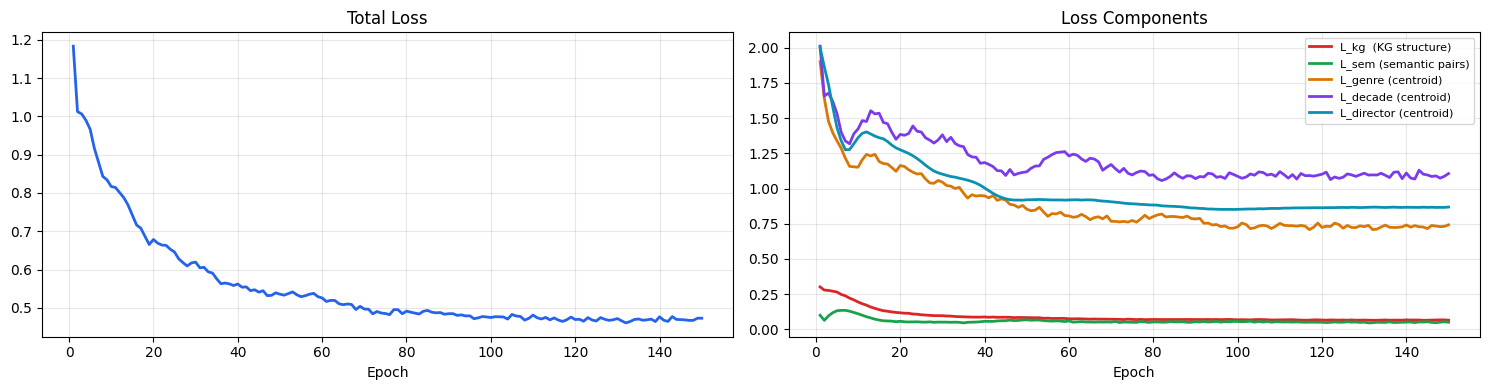

✅ Loss curve saved

Loss diagnostics:
  Total loss should decrease steadily and plateau — if it keeps
  dropping at epoch 80, increase EPOCHS.

  l_kg should drop and stabilize below 0.1 — if stuck near 0.3
  the margin is too large or the graph is too sparse.

  l_sem should drop but not to 0 — some pairs are hard negatives.
  If it stays near 0.3 the whole time, lower SIM_THRESH.

  l_genre should be small and stable — it's a soft regularizer,
  not a primary objective. If it dominates, lower LAMBDA_GENRE.



In [ ]:


hist = pd.read_csv(f"{CACHE_DIR}/training_history.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

ax1.plot(hist["epoch"], hist["loss"], color="#2563eb", lw=2)
ax1.set_title("Total Loss"); ax1.set_xlabel("Epoch")
ax1.grid(alpha=0.3)

plot_terms = {
    "l_kg":       ("#dc2626", "L_kg  (KG structure)"),
    "l_sem":      ("#16a34a", "L_sem (semantic pairs)"),
    "l_genre":    ("#d97706", "L_genre (centroid)"),
    "l_decade":   ("#7c3aed", "L_decade (centroid)"),
    "l_director": ("#0891b2", "L_director (centroid)"),
}
for col, (color, label) in plot_terms.items():
    if col in hist.columns:
        ax2.plot(hist["epoch"], hist[col], color=color, lw=2, label=label)
ax2.set_title("Loss Components"); ax2.set_xlabel("Epoch")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/loss_curve.png", dpi=150)
plt.show()


print("✅ Loss curve saved")

print("""
Loss diagnostics:
  Total loss should decrease steadily and plateau — if it keeps
  dropping at epoch 80, increase EPOCHS.

  l_kg should drop and stabilize below 0.1 — if stuck near 0.3
  the margin is too large or the graph is too sparse.

  l_sem should drop but not to 0 — some pairs are hard negatives.
  If it stays near 0.3 the whole time, lower SIM_THRESH.

  l_genre should be small and stable — it's a soft regularizer,
  not a primary objective. If it dominates, lower LAMBDA_GENRE.
""")

In [ ]:

def mid_to_title(mid):
    row = movies_subset[movies_subset["movieId"] == mid]["title_clean"]
    return row.values[0] if len(row) > 0 else str(mid)

def find_similar_movies(query_title, emb_matrix, id_list, top_k=7, label=""):
    title_map = {}
    for mid in id_list:
        row = movies_subset[movies_subset["movieId"] == mid]
        if not row.empty:
            title_map[row.iloc[0]["title_clean"].lower()] = mid

    matched = title_map.get(query_title.lower())
    if matched is None:
        for t, mid in title_map.items():
            if query_title.lower() in t:
                matched = mid; break
    if matched is None:
        print(f"  '{query_title}' not found"); return

    idx  = id_list.index(matched)
    q    = emb_matrix[idx]
    sims = emb_matrix @ q
    sims[idx] = -1.0
    top  = np.argsort(sims)[::-1][:top_k]
    print(f"\n  [{label}] Similar to '{mid_to_title(matched)}':")
    for i in top:
        print(f"    {mid_to_title(id_list[i]):<50}  {sims[i]:.3f}")


def entity_ranking(entity_name, entity_emb_matrix, entity_vocab,
                   movie_emb_matrix=None, top_k=5, label=""):
    """Find movies most aligned with a given entity (genre, decade, keyword…)"""
    if movie_emb_matrix is None:
        movie_emb_matrix = graph_emb_movie
    norm_name = entity_name.lower()
    matches = [v for v in entity_vocab if norm_name in v.lower()]
    if not matches:
        print(f"  '{entity_name}' not found in vocab"); return
    name = matches[0]
    idx  = entity_vocab.index(name)
    e_emb = entity_emb_matrix[idx]
    sims  = movie_emb_matrix @ e_emb
    top   = np.argsort(sims)[::-1][:top_k]
    print(f"\n  [{label}] Top movies for '{name}':")
    for i in top:
        print(f"    {mid_to_title(movie_ids[i]):<50}  {sims[i]:.3f}")



In [ ]:

print("=" * 65)
print("TEST A — MOVIE SIMILARITY: graph vs semantic")
for title in ["The Matrix", "Toy Story", "Pulp Fiction", "Alien", "Schindler's List"]:
    find_similar_movies(title, graph_emb_movie,      movie_ids, label="GRAPH")
    find_similar_movies(title, semantic_embeddings,  movie_ids, label="SEMANTIC")

# ── What to look for ─────────────────────────────────────────
print("""
Expected pattern:
  GRAPH neighbors share cast, director, genre structure.
    "Alien" → other Ridley Scott sci-fi / horror films.
  SEMANTIC neighbors share thematic language.
    "Alien" → other "isolated crew in danger" films regardless of director.
  Overlap between them = high-confidence recommendations.
""")


TEST A — MOVIE SIMILARITY: graph vs semantic

  [GRAPH] Similar to 'Return to Source: The Philosophy of The Matrix':
    The Matrix Revisited                                0.987
    Dangerous Days: Making Blade Runner                 0.969
    The Making of 'Terminator 2: Judgment Day'          0.962
    Man on a Mission: Richard Garriott's Road to the Stars  0.961
    Lovecraft: Fear of the Unknown                      0.961
    Pax Americana and the Weaponization of Space        0.961
    Close Encounters of the Fifth Kind                  0.960

  [SEMANTIC] Similar to 'Return to Source: The Philosophy of The Matrix':
    The Matrix Revisited                                0.905
    Matrix Reloaded, The                                0.859
    The Matrix Resurrections                            0.853
    Matrix, The                                         0.841
    In Search of Tomorrow                               0.839
    Room 237                                            0.83

In [ ]:
print("=" * 65)
print("TEST B — GENRE RANKING  (movie · genre_emb)")
graph_emb_genre = graph_embs["genre"]
genre_vocab     = graph_meta["genre_vocab"]

for gname in ["Action", "Animation", "Horror", "Drama", "Comedy", "Science Fiction"]:
    entity_ranking(gname, graph_emb_genre, genre_vocab, label="GENRE")



In [ ]:
print("=" * 65)
print("TEST C — DECADE RANKING  (movie · decade_emb)")
graph_emb_decade = graph_embs["decade"]
decade_vocab     = graph_meta["decade_vocab"]

for decade in ["1970s", "1980s", "1990s", "2000s", "2010s"]:
    entity_ranking(decade, graph_emb_decade, decade_vocab, label="DECADE")


print("""
Decade ranking tells you:
  If 1990s movies cluster near the 1990s node, the GAT has learned
  temporal structure — movies from the same era are structurally
  related even beyond just sharing a decade node, because they tend
  to share cast and genre patterns of that era.
  This powers a "1990s vibe" slider later.
""")

In [ ]:

print("=" * 65)
print("TEST D — KEYWORD RANKING  (movie · keyword_emb)")
graph_emb_keyword = graph_embs["keyword"]
kw_vocab          = graph_meta["kw_vocab"]

# Pick some interesting keywords from the vocab
sample_kws = [kw for kw in kw_vocab if any(
    term in kw.lower() for term in
    ["based on novel", "space", "murder", "friendship", "war", "love"]
)][:6]

for kw in sample_kws:
    entity_ranking(kw, graph_emb_keyword, kw_vocab, label="KEYWORD")

In [ ]:
# CELL 15E — TEST E: QUERY COMPARISON (semantic vs graph)
# ================================================================
# This is the core retrieval test for the app.
# For each text query:
#   1. Semantic search: encode query → cosine sim vs embedding_semantic
#   2. Graph search: use top semantic hit's graph embedding as pivot
#      → cosine sim vs embedding_graph
# The pivot approach is necessary because there is no direct text→graph
# embedding function. We need to keep BOTH embeddings per movie.

from transformers import AutoModel

print("Loading Jina for query encoding…")
jina_model = AutoModel.from_pretrained(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
).to(DEVICE)
jina_model.eval()


def encode_query(text):
    with torch.no_grad():
        emb = jina_model.encode(
            texts=[text], task="retrieval",
            prompt_name="query", truncate_dim=JINA_TRUNCATE_DIM,
        )
    if isinstance(emb, torch.Tensor):
        emb = emb.cpu().float().numpy()
    emb = np.array(emb[0], dtype=np.float32)
    return emb / (np.linalg.norm(emb) + 1e-8)


def query_comparison(query_text, top_k=7):
    q_emb = encode_query(query_text)

    # Semantic ranking
    sem_sims = semantic_embeddings @ q_emb
    sem_top  = np.argsort(sem_sims)[::-1][:top_k]

    # Graph ranking via pivot
    pivot_idx   = sem_top[0]
    graph_query = graph_emb_movie[pivot_idx]
    graph_sims  = graph_emb_movie @ graph_query
    graph_sims[pivot_idx] = -1.0
    graph_top   = np.argsort(graph_sims)[::-1][:top_k]

    pivot_title = mid_to_title(movie_ids[pivot_idx])
    print(f"\n{'='*72}")
    print(f"  QUERY : \"{query_text}\"")
    print(f"  Pivot : {pivot_title}  (top semantic hit used as graph anchor)")
    print(f"{'='*72}")
    print(f"  {'SEMANTIC':<40}  {'GRAPH (pivot-based)':<40}")
    print(f"  {'-'*40}  {'-'*40}")

    for r in range(top_k):
        st = mid_to_title(movie_ids[sem_top[r]])
        gt = mid_to_title(movie_ids[graph_top[r]])
        st = (st[:37]+"...") if len(st) > 40 else st
        gt = (gt[:37]+"...") if len(gt) > 40 else gt
        ss = sem_sims[sem_top[r]]
        gs = graph_sims[graph_top[r]]
        print(f"  {st:<40}  {gt:<40}  ({ss:.3f} / {gs:.3f})")

    overlap = (set(movie_ids[i] for i in sem_top) &
               set(movie_ids[i] for i in graph_top))
    if overlap:
        print(f"\n  ✅ Overlap ({len(overlap)}): "
              + ", ".join(mid_to_title(m) for m in overlap))
    else:
        print(f"\n  ⚠️  No overlap — spaces disagree (expected for vibe queries)")


queries = [
    "slow atmospheric sci-fi about communication with aliens",
    "dark psychological thriller where nothing is what it seems",
    "feel-good animated movie for the whole family",
    "gritty 1970s crime drama with morally ambiguous characters",
    "90s action blockbuster with a charismatic hero",
    "visually stunning film with nonlinear timeline and philosophy",
    "low-budget horror relying on tension rather than gore",
    "romantic drama set in wartime Europe",
]

for q in queries:
    query_comparison(q, top_k=7)

del jina_model; gc.collect(); torch.cuda.empty_cache()

print(textwrap.dedent("""

  INTERPRETATION GUIDE
  ════════════════════
  Semantic  → text/vibe match. Use this for the main search bar.
  Graph     → structural match (shared KG neighbors). Use this for
              "more like this movie" and slider steering.

  High overlap → both spaces agree → highest-confidence recommendations.
  Low overlap on vibe queries → normal; semantic is doing the work.
  Low overlap on "movies like X" → graph is doing the work.

  Entity embeddings (genre, decade, keyword, director, actor, language,
  country) power the sliders:
    steered = normalize(q_graph + α * genre_emb["Action"]
                                + β * decade_emb["1990s"])
  This lets users mix structural signals without any text.
"""))
